# Chapter 1: Euclidean Spaces

**Source Span.** `An Introduction to Manifolds.pdf`, printed pages `3-47` (PDF pages `22-66`). The span read for this revision covers smooth functions on Euclidean space, Taylor remainders, tangent vectors as derivations, germs, vector fields, exterior algebra of multicovectors, wedge products, differential forms on `R^n`, the exterior derivative, closed and exact forms, and the vector-calculus dictionary.

**Chapter Goal.** Rebuild ordinary multivariable calculus in a form that survives the move to manifolds. The chapter starts in the most familiar place, `R^n`, but it steadily removes accidental dependence on global coordinates. Smooth functions are treated by what all derivatives do, tangent vectors become derivations on germs of functions, wedge products encode oriented measurement, and differential forms become the objects that carry integration and vector calculus into later chapters.

The notebook is intentionally not a replacement for every proof in the text. It is a working laboratory for the chapter's definitions and proof moves. Each visual below has an inspection target: flatness versus analyticity, derivations versus arrows, the sign rules behind alternating forms, and the invariant checks behind `d^2 = 0`, exactness, and closedness. The examples are original computational models chosen to expose the same mathematical structure without copying the book's prose or figures.

## Visual Storyboard

1. **Flat but smooth is not analytic.** A plot of a standard flat function near the origin, together with Taylor polynomial behavior, makes visible why `C^infty` smoothness is weaker than analyticity. Inspection target: the function is nonzero for positive `x`, but every sampled ratio `f(x)/x^k` collapses toward zero near the origin.
2. **Tangent vectors as derivations.** A contour/surface view of a scalar field at a point compares the geometric arrow `v` with the algebraic rule `D_v f = grad f dot v`. Inspection target: the same number appears from a directional derivative, a gradient pairing, and a Leibniz-rule derivation check.
3. **Exterior algebra sign mechanics.** A wedge-basis table and sign heatmap show why alternating multilinear functions change sign under swaps and vanish on repeated directions. Inspection target: permutation parity and the binomial count of `k`-covector basis elements.
4. **Differential forms on Euclidean space.** A vector-calculus form model compares exact, closed, and non-exact behavior through symbolic exterior derivatives and a circulation calculation around an annulus. Inspection target: local derivative tests do not always detect global potential functions.

## Library Routing

| Chapter concept | Representation | Library | Why this route |
| --- | --- | --- | --- |
| Smooth versus analytic | sampled flat function and Taylor remainder table | NumPy, Matplotlib | the limiting behavior is visual and numerical before it is formal |
| Derivations at a point | surface/contour plus symbolic derivative checks | SymPy, Matplotlib | connects arrows, partial derivatives, and the Leibniz identity |
| Exterior algebra | wedge sign tables and combinatorial counts | Python itertools, SymPy, Matplotlib | permutation signs are discrete and easier to audit as a table |
| Exterior derivative | symbolic coefficients plus circulation experiment | SymPy, NumPy, Matplotlib | exact/closed checks become executable identities and integrals |

In [1]:
from pathlib import Path
import csv
import itertools
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "source_map.json").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate An-Introduction-to-Manifolds book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-01-euclidean-spaces"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIG = ARTIFACT_ROOT / "figures"
CHECK = ARTIFACT_ROOT / "checks"
TABLE = ARTIFACT_ROOT / "tables"
created_artifacts = []

def keep(path):
    created_artifacts.append(Path(path))
    return path

print(f"Artifacts: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Artifacts: artifacts\chapter-01-euclidean-spaces


## Translation Guide

The chapter's first move is to distinguish the amount of differentiability needed for manifold theory. A `C^infty` function can be differentiated forever, but its Taylor series at a point need not determine it. This matters later because manifolds are glued from smooth coordinate changes rather than from convergent power series. The computational habit is to treat smoothness through local tests: derivatives exist, transition rules behave, and formulas can be restricted to a neighborhood or a germ.

The second move is the decisive one. A tangent vector at `p` in `R^n` can be pictured as an arrow, but the arrow picture is not portable enough. The chapter replaces it by a derivation: a linear operator on germs of smooth functions at `p` satisfying the Leibniz rule. Once a tangent vector is a derivation, vector fields become derivations of the algebra of smooth functions, and later the same definition works on manifolds without needing ambient arrows.

The third move builds the algebra needed by forms. A covector eats one vector. A `k`-covector eats `k` vectors multilinearly, and alternating `k`-covectors record oriented `k`-dimensional measurement. The wedge product is the multiplication rule that keeps this orientation bookkeeping honest. Differential forms then attach these alternating covectors smoothly to points of `R^n`; the exterior derivative is the coordinate formula that packages gradient, curl, and divergence patterns into one operation.

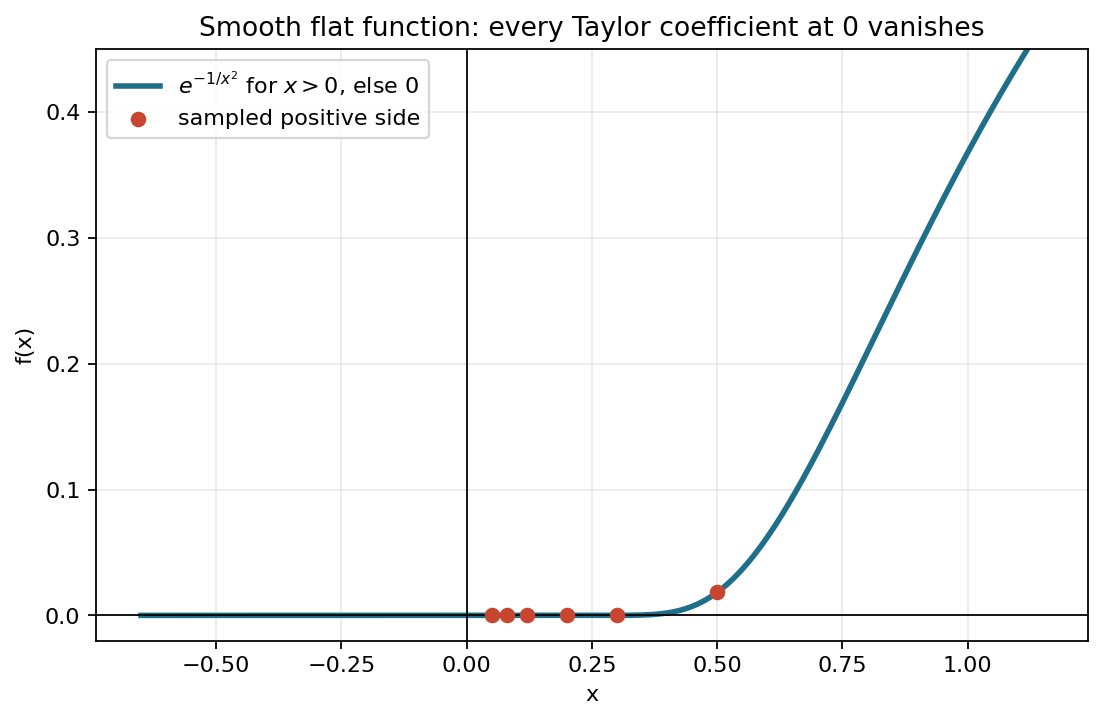

{'sample_count': 6,
 'all_ratios_small_at_0_05': True,
 'taylor_polynomial_at_origin_sampled': 'zero polynomial',
 'nonzero_positive_side': True}

In [2]:
# Smooth but non-analytic: a flat function at the origin.
def flat_function(values):
    values = np.asarray(values, dtype=float)
    out = np.zeros_like(values)
    mask = values > 0
    out[mask] = np.exp(-1.0 / values[mask] ** 2)
    return out

x_grid = np.linspace(-0.65, 1.15, 700)
y_flat = flat_function(x_grid)
positive_samples = np.array([0.5, 0.3, 0.2, 0.12, 0.08, 0.05])
ratio_rows = []
for x0 in positive_samples:
    row = {"x": float(x0), "f(x)": float(flat_function([x0])[0])}
    for power in [1, 2, 3, 4, 5]:
        row[f"f(x)/x^{power}"] = float(flat_function([x0])[0] / (x0 ** power))
    ratio_rows.append(row)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(x_grid, y_flat, color="#1f6f8b", lw=2.5, label=r"$e^{-1/x^2}$ for $x>0$, else $0$")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.scatter(positive_samples, flat_function(positive_samples), color="#c84630", zorder=3, label="sampled positive side")
ax.set_title("Smooth flat function: every Taylor coefficient at 0 vanishes")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_ylim(-0.02, 0.45)
ax.legend(loc="upper left")
ax.grid(alpha=0.25)
flat_path = keep(save_matplotlib(fig, FIG / "flat-smooth-nonanalytic.png"))
plt.close(fig)
ratio_path = keep(save_csv(ratio_rows, TABLE / "flat-function-ratios.csv"))
flat_check = {
    "sample_count": len(ratio_rows),
    "all_ratios_small_at_0_05": all(abs(ratio_rows[-1][f"f(x)/x^{p}"]) < 1e-120 for p in [1, 2, 3, 4, 5]),
    "taylor_polynomial_at_origin_sampled": "zero polynomial",
    "nonzero_positive_side": bool(flat_function([0.5])[0] > 0),
}
flat_check_path = keep(save_json(flat_check, CHECK / "flat-smooth-nonanalytic-check.json"))
display_artifact(flat_path, width=760)
flat_check

## Tangent Vectors as Derivations

A directional derivative looks like a limit along a line, but the chapter asks us to remember the operation it performs on functions. At a point `p`, the vector `v` defines `D_v(f)`. Linearity and the product rule say that this operator only needs the germ of `f` near `p`. That is why the definition is ready for manifolds: it refers to local smooth functions rather than to a global embedding.

The next cell uses one scalar field and one test product to check the three faces of the same object. The number `D_v f(p)` is computed from a gradient pairing, from a symbolic directional derivative, and from the derivation identity on `f g`. The visual marks the point and vector on level curves so the algebra is tied to the geometry.

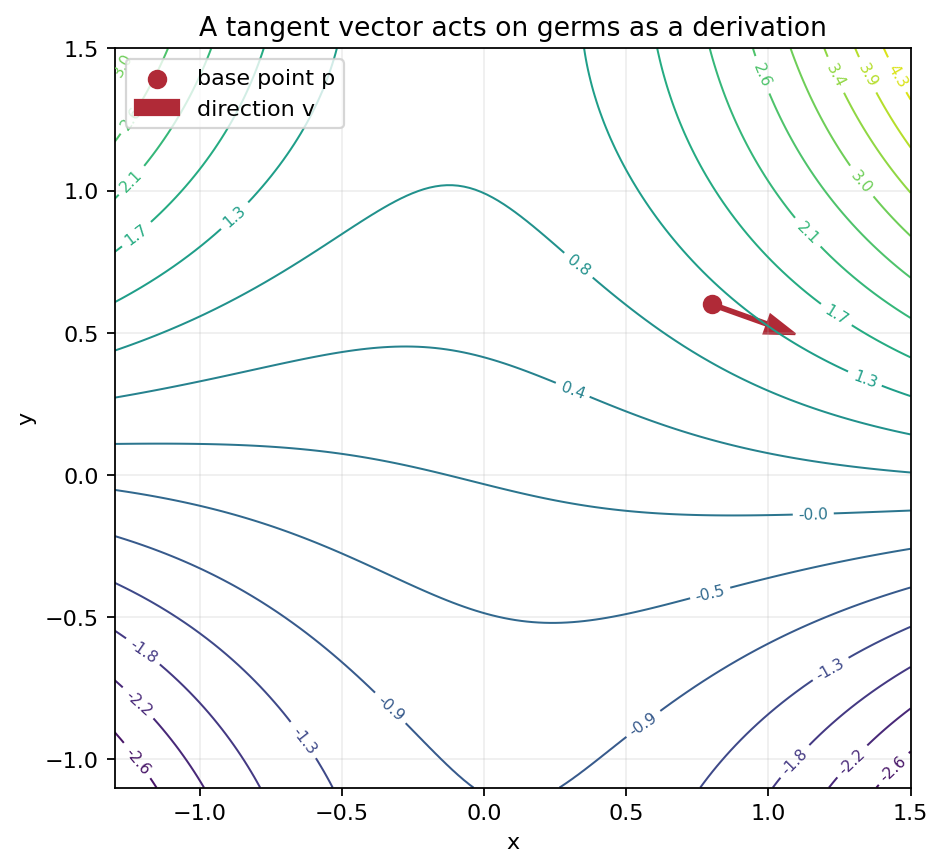

{'D_v_f_from_gradient': '687/1000 - cos(3/5)/4',
 'D_v_f_from_curve': '687/1000 - cos(3/5)/4',
 'same_directional_value': True,
 'leibniz_residual': '0'}

In [3]:
x, y, s = sp.symbols("x y s", real=True)
f_expr = x**2 * y + sp.sin(y) + sp.Rational(1, 4) * x
g_expr = sp.exp(x - y) + x*y
p = {x: sp.Rational(4, 5), y: sp.Rational(3, 5)}
v = sp.Matrix([sp.Rational(7, 10), -sp.Rational(1, 4)])
grad_f = sp.Matrix([sp.diff(f_expr, x), sp.diff(f_expr, y)])
directional_from_gradient = sp.simplify((grad_f.dot(v)).subs(p))
line_subs = {x: p[x] + s * v[0], y: p[y] + s * v[1]}
directional_from_curve = sp.simplify(sp.diff(f_expr.subs(line_subs), s).subs(s, 0))
D_fg = sp.simplify(sp.diff((f_expr * g_expr).subs(line_subs), s).subs(s, 0))
leibniz_rhs = sp.simplify(directional_from_curve * g_expr.subs(p) + f_expr.subs(p) * sp.diff(g_expr.subs(line_subs), s).subs(s, 0))

xx = np.linspace(-1.3, 1.5, 140)
yy = np.linspace(-1.1, 1.5, 140)
XX, YY = np.meshgrid(xx, yy)
ZZ = XX**2 * YY + np.sin(YY) + 0.25 * XX
fig, ax = plt.subplots(figsize=(7.2, 6.0))
levels = np.linspace(float(ZZ.min()), float(ZZ.max()), 19)
contours = ax.contour(XX, YY, ZZ, levels=levels, cmap="viridis", linewidths=0.9)
ax.clabel(contours, inline=True, fontsize=7, fmt="%.1f")
px, py = float(p[x]), float(p[y])
vx, vy = float(v[0]), float(v[1])
ax.scatter([px], [py], color="#b02a37", s=60, zorder=4, label="base point p")
ax.arrow(px, py, vx * 0.42, vy * 0.42, width=0.012, head_width=0.07, color="#b02a37", length_includes_head=True, label="direction v")
ax.set_aspect("equal", adjustable="box")
ax.set_title("A tangent vector acts on germs as a derivation")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper left")
ax.grid(alpha=0.2)
derivation_path = keep(save_matplotlib(fig, FIG / "derivation-directional-derivative.png"))
plt.close(fig)
derivation_check = {
    "D_v_f_from_gradient": str(directional_from_gradient),
    "D_v_f_from_curve": str(directional_from_curve),
    "same_directional_value": bool(sp.simplify(directional_from_gradient - directional_from_curve) == 0),
    "leibniz_residual": str(sp.simplify(D_fg - leibniz_rhs)),
}
derivation_check_path = keep(save_json(derivation_check, CHECK / "derivation-leibniz-check.json"))
display_artifact(derivation_path, width=720)
derivation_check

## Exterior Algebra of Multicovectors

A basis for covectors is dual to a basis for vectors: it picks out coordinates. Multicovectors are multilinear functions of several vector inputs. The alternating ones are the geometric measurements: they change sign when two inputs are swapped and vanish when two inputs are equal. The wedge product is therefore not a decorative multiplication symbol; it is the operation that builds oriented area, volume, and higher-dimensional measurement from covectors.

The source span spends real effort on permutations, alternating operators, tensor products, wedge products, anticommutativity, associativity, and bases for `k`-covectors. The next experiment turns those rules into a table. If `i=j`, `dx_i wedge dx_j` is zero. If `i != j`, swapping the order flips the sign. The binomial count checks the size of a basis for alternating `k`-covectors in dimension `n`.

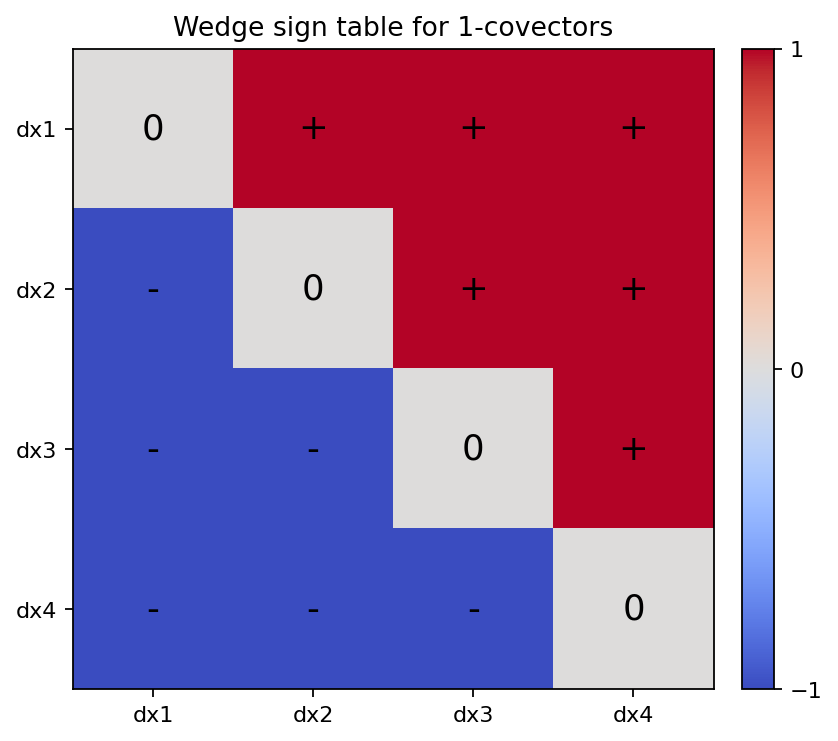

{'dx2_wedge_dx1': '-dx1 wedge dx2',
 'dx3_wedge_dx3_zero': True,
 'dimension_5_two_covectors': 10,
 'permutation_3_1_2_parity': 1}

In [4]:
def inversion_parity(order):
    inv = sum(1 for i in range(len(order)) for j in range(i + 1, len(order)) if order[i] > order[j])
    return -1 if inv % 2 else 1

basis = ["dx1", "dx2", "dx3", "dx4"]
wedge_rows = []
sign_matrix = np.zeros((4, 4), dtype=int)
for i, left in enumerate(basis):
    for j, right in enumerate(basis):
        if i == j:
            sign = 0
            canonical = "0"
        elif i < j:
            sign = 1
            canonical = f"{left} wedge {right}"
        else:
            sign = -1
            canonical = f"-{right} wedge {left}"
        sign_matrix[i, j] = sign
        wedge_rows.append({"left": left, "right": right, "canonical_result": canonical, "sign": sign})

basis_count_rows = []
for n in range(2, 7):
    for k in range(0, n + 1):
        basis_count_rows.append({"n": n, "k": k, "basis_count": math.comb(n, k)})

fig, ax = plt.subplots(figsize=(5.8, 5.2))
im = ax.imshow(sign_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(4), basis)
ax.set_yticks(range(4), basis)
for i in range(4):
    for j in range(4):
        label = "0" if sign_matrix[i, j] == 0 else ("+" if sign_matrix[i, j] > 0 else "-")
        ax.text(j, i, label, ha="center", va="center", fontsize=16, color="black")
ax.set_title("Wedge sign table for 1-covectors")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[-1, 0, 1])
wedge_path = keep(save_matplotlib(fig, FIG / "wedge-sign-basis-table.png"))
plt.close(fig)
wedge_table_path = keep(save_csv(wedge_rows, TABLE / "wedge-sign-table.csv"))
basis_count_path = keep(save_csv(basis_count_rows, TABLE / "alternating-basis-counts.csv"))
wedge_check = {
    "dx2_wedge_dx1": next(r for r in wedge_rows if r["left"] == "dx2" and r["right"] == "dx1")["canonical_result"],
    "dx3_wedge_dx3_zero": next(r for r in wedge_rows if r["left"] == "dx3" and r["right"] == "dx3")["sign"] == 0,
    "dimension_5_two_covectors": math.comb(5, 2),
    "permutation_3_1_2_parity": inversion_parity([3, 1, 2]),
}
wedge_check_path = keep(save_json(wedge_check, CHECK / "wedge-algebra-check.json"))
display_artifact(wedge_path, width=600)
wedge_check

## Differential Forms and the Exterior Derivative on `R^n`

A differential `k`-form on Euclidean space assigns an alternating `k`-covector smoothly to every point. The exterior derivative is the operation that raises degree by one and satisfies the same structural rules everywhere: it is linear, obeys a graded product rule, and squares to zero. In low dimensions, the formulas recover familiar vector-calculus operators. For a 1-form `P dx + Q dy`, the exterior derivative has coefficient `Q_x - P_y`, the scalar curl in the plane.

Closed and exact forms are already visible in Euclidean examples. Exact forms are closed because `d^2 = 0`. On simply connected regions the converse is often friendly, but punctures create global phenomena: the angular form around the origin is closed away from the origin and still has nonzero circulation around a circle. This is a preview of de Rham cohomology, but Chapter 1 supplies the computational language.

C:\Users\rahul\AppData\Local\Temp\ipykernel_32828\3121685232.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  circulation = float(np.trapz(P_vals * dx_dt + Q_vals * dy_dt, theta))
C:\Users\rahul\AppData\Local\Temp\ipykernel_32828\3121685232.py:22: RuntimeWarning: invalid value encountered in divide
  UU = np.where(mask, -YY / RR, np.nan)
C:\Users\rahul\AppData\Local\Temp\ipykernel_32828\3121685232.py:23: RuntimeWarning: invalid value encountered in divide
  VV = np.where(mask, XX / RR, np.nan)


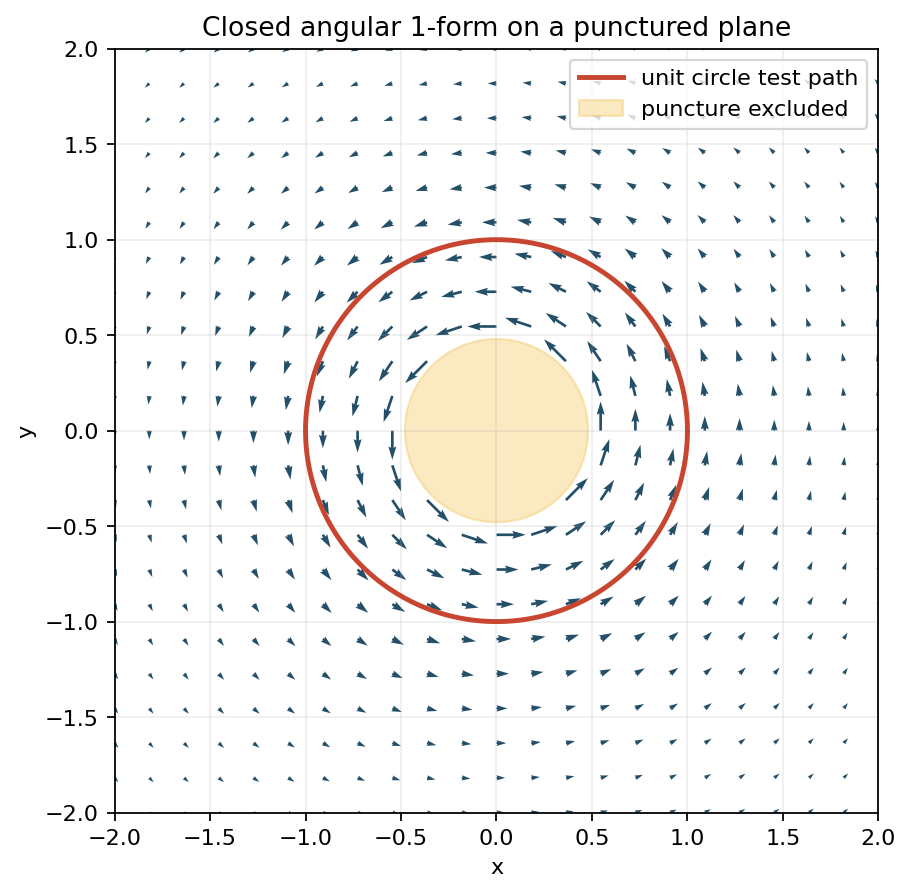

{'exact_form_curl_residual': '0',
 'angular_form_curl_residual_away_from_origin': '0',
 'unit_circle_circulation_numeric': 6.27271333166762,
 'circulation_error_from_2pi': 0.010471975511966214}

In [5]:
P_exact = sp.diff(x**2 * y + sp.sin(y), x)
Q_exact = sp.diff(x**2 * y + sp.sin(y), y)
exact_curl = sp.simplify(sp.diff(Q_exact, x) - sp.diff(P_exact, y))
P_swirl = -y / (x**2 + y**2)
Q_swirl = x / (x**2 + y**2)
swirl_curl = sp.simplify(sp.diff(Q_swirl, x) - sp.diff(P_swirl, y))

theta = np.linspace(0, 2 * np.pi, 600, endpoint=False)
r = 1.0
circle_x = r * np.cos(theta)
circle_y = r * np.sin(theta)
dx_dt = -r * np.sin(theta)
dy_dt = r * np.cos(theta)
P_vals = -circle_y / (circle_x**2 + circle_y**2)
Q_vals = circle_x / (circle_x**2 + circle_y**2)
circulation = float(np.trapz(P_vals * dx_dt + Q_vals * dy_dt, theta))

grid = np.linspace(-2.0, 2.0, 23)
XX, YY = np.meshgrid(grid, grid)
RR = XX**2 + YY**2
mask = RR > 0.25
UU = np.where(mask, -YY / RR, np.nan)
VV = np.where(mask, XX / RR, np.nan)
fig, ax = plt.subplots(figsize=(6.8, 6.2))
ax.quiver(XX, YY, UU, VV, color="#234f68", angles="xy", scale_units="xy", scale=12, width=0.0035)
ax.plot(circle_x, circle_y, color="#c84630", lw=2.2, label="unit circle test path")
ax.add_patch(plt.Circle((0, 0), 0.48, color="#f2c14e", alpha=0.35, label="puncture excluded"))
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_title("Closed angular 1-form on a punctured plane")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right")
ax.grid(alpha=0.2)
forms_path = keep(save_matplotlib(fig, FIG / "closed-angular-form-circulation.png"))
plt.close(fig)
forms_check = {
    "exact_form_curl_residual": str(exact_curl),
    "angular_form_curl_residual_away_from_origin": str(swirl_curl),
    "unit_circle_circulation_numeric": circulation,
    "circulation_error_from_2pi": abs(circulation - 2 * math.pi),
}
forms_check_path = keep(save_json(forms_check, CHECK / "exterior-derivative-circulation-check.json"))
display_artifact(forms_path, width=650)
forms_check

## Applied Lab

Use this cell as a controlled test bench for the chapter. Change the coefficient functions in the 1-form, the dimension in the exterior algebra table, or the vector used in the derivation example. A correct experiment should preserve the structural checks: derivations obey the product rule, repeated wedge factors vanish, exact forms have zero exterior derivative, and applying `d` twice should erase a form by equality of mixed partials.

The final symbolic check below verifies `d(d alpha)=0` for a general-looking 1-form in three variables. It also records the basis sizes for forms in dimensions one through six. This is the sort of small invariant ledger that keeps later manifold calculations honest: when a notebook claims to manipulate forms, it should expose the coefficients and the identities that make the manipulation legal.

In [6]:
z = sp.symbols("z", real=True)
A = x*y + sp.sin(z)
B = y*z + sp.cos(x)
C = z*x + sp.sin(y)
# d alpha has coefficients on dx^dy, dx^dz, dy^dz.
dA = {x: sp.diff(A, x), y: sp.diff(A, y), z: sp.diff(A, z)}
dB = {x: sp.diff(B, x), y: sp.diff(B, y), z: sp.diff(B, z)}
dC = {x: sp.diff(C, x), y: sp.diff(C, y), z: sp.diff(C, z)}
F_xy = sp.simplify(dB[x] - dA[y])
F_xz = sp.simplify(dC[x] - dA[z])
F_yz = sp.simplify(dC[y] - dB[z])
# coefficient of dx^dy^dz in d(d alpha)
d2_coeff = sp.simplify(sp.diff(F_yz, x) - sp.diff(F_xz, y) + sp.diff(F_xy, z))
lab_report = {
    "d_alpha_coefficients": {"dx^dy": str(F_xy), "dx^dz": str(F_xz), "dy^dz": str(F_yz)},
    "d_squared_alpha_coefficient": str(d2_coeff),
    "d_squared_zero": bool(d2_coeff == 0),
    "basis_counts_by_dimension": {str(n): [math.comb(n, k) for k in range(n + 1)] for n in range(1, 7)},
}
lab_report_path = keep(save_json(lab_report, CHECK / "applied-lab-d-squared-check.json"))
lab_report

{'d_alpha_coefficients': {'dx^dy': '-x - sin(x)',
  'dx^dz': 'z - cos(z)',
  'dy^dz': '-y + cos(y)'},
 'd_squared_alpha_coefficient': '0',
 'd_squared_zero': True,
 'basis_counts_by_dimension': {'1': [1, 1],
  '2': [1, 2, 1],
  '3': [1, 3, 3, 1],
  '4': [1, 4, 6, 4, 1],
  '5': [1, 5, 10, 10, 5, 1],
  '6': [1, 6, 15, 20, 15, 6, 1]}}

## Takeaways

- The chapter turns `R^n` from a place with convenient coordinates into a testing ground for coordinate-independent ideas.
- Smoothness is local and flexible; analyticity is much more rigid. The flat-function visual keeps that distinction visible.
- A tangent vector is more than an arrow: as a derivation, it is a linear product-rule operator on germs of smooth functions.
- Alternating forms are built from covectors by sign-sensitive wedge products. Repeated directions vanish because alternating measurement has zero volume when directions collapse.
- The exterior derivative packages several vector-calculus operations and always satisfies `d^2 = 0`. Closed/exact behavior begins in Euclidean space and becomes topological later.

The final sanity cell checks that every artifact exists, the core symbolic identities vanish as expected, and the one global circulation experiment really detects the puncture.

In [7]:
# final_sanity
final_sanity = {
    "flat_nonanalytic_visible": flat_check["nonzero_positive_side"] and flat_check["all_ratios_small_at_0_05"],
    "derivation_matches_gradient": derivation_check["same_directional_value"] and derivation_check["leibniz_residual"] == "0",
    "wedge_repeated_factor_zero": wedge_check["dx3_wedge_dx3_zero"],
    "exact_form_closed": forms_check["exact_form_curl_residual"] == "0",
    "angular_form_closed_off_origin": forms_check["angular_form_curl_residual_away_from_origin"] == "0",
    "d_squared_zero": lab_report["d_squared_zero"],
    "artifact_count": len(created_artifacts),
}
final_sanity_path = keep(save_json(final_sanity, CHECK / "final-sanity.json"))
assert final_sanity["flat_nonanalytic_visible"]
assert final_sanity["derivation_matches_gradient"]
assert final_sanity["wedge_repeated_factor_zero"]
assert final_sanity["exact_form_closed"]
assert final_sanity["angular_form_closed_off_origin"]
assert final_sanity["d_squared_zero"]
assert forms_check["circulation_error_from_2pi"] < 0.02
assert_artifacts(created_artifacts, min_bytes=40)
final_sanity

{'flat_nonanalytic_visible': True,
 'derivation_matches_gradient': True,
 'wedge_repeated_factor_zero': True,
 'exact_form_closed': True,
 'angular_form_closed_off_origin': True,
 'd_squared_zero': True,
 'artifact_count': 12}